In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from astropy.stats import sigma_clip
from scipy.stats import binned_statistic

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



776 SNe before paper-based quality cuts.
579 SNe after paper-based quality cuts.
776 SNe before paper-based quality cuts (df2).
579 SNe after paper-based quality cuts (df2).
579 SNe after LOGMSTAR cut (raw full sample).
579 SNe after x1 cut (raw full sample).
579 SNe after c cut (raw full sample).


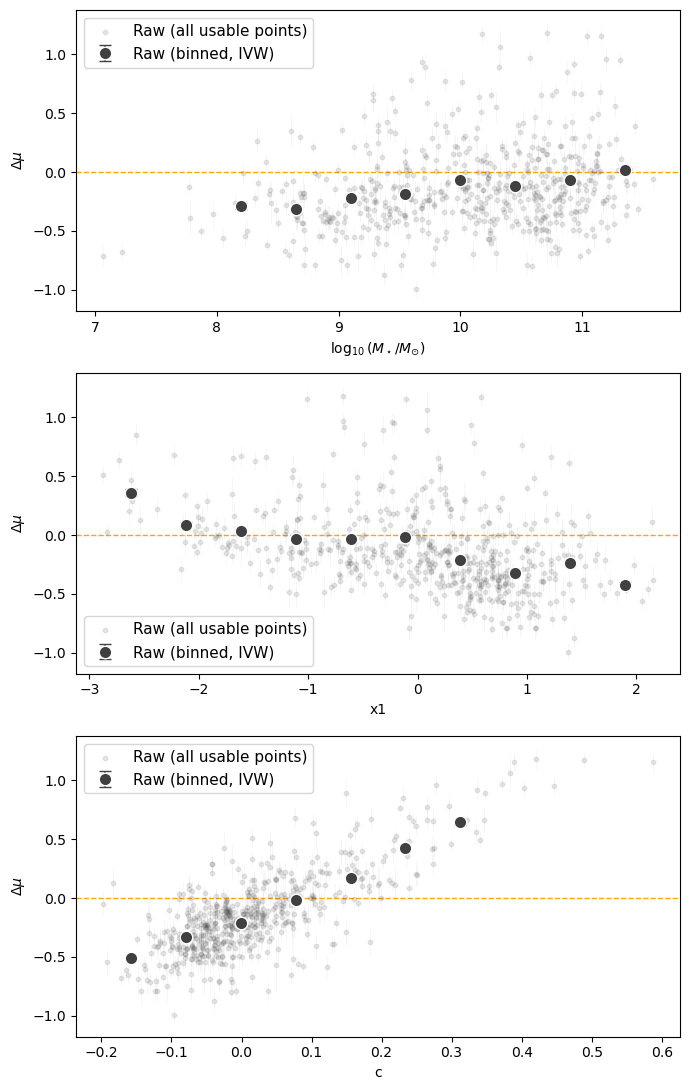

In [ ]:
# =====================================================
# Read in FIRST dataset
# =====================================================

df = pd.read_csv(
    "ZTF_DESI_data/ZTF_resid_cent_hostprop_no_x1_c.csv"
)

# -----------------------------------------------------
# DATA FILTER - Paper lccoverage_flag and fitquality_flag
# -------------------------------------------------------
print(len(df), "SNe before paper-based quality cuts.")
df = df[(df["lccoverage_flag"] == 1) & (df["fitquality_flag"] == 1)]
print(len(df), "SNe after paper-based quality cuts.")

# --------------------------------------
# Create g - r host-galaxy color
# --------------------------------------
df["SDSS_g_minus_r"] = df["ABSMAG01_SDSS_G"] - df["ABSMAG01_SDSS_R"]

# Read the Error Collumn for the distance modulus measurements.
yerr_all = df["sigma_mu_meas"]


# =====================================================
# Read in SECOND dataset (NEW)
# =====================================================

df2 = pd.read_csv(
    "ZTF_DESI_data/ZTF_resid_cent_hostprop_no_x1_c.csv"
)

# -----------------------------------------------------
# DATA FILTER - Paper lccoverage_flag and fitquality_flag
# -------------------------------------------------------
print(len(df2), "SNe before paper-based quality cuts (df2).")
df2 = df2[(df2["lccoverage_flag"] == 1) & (df2["fitquality_flag"] == 1)]
print(len(df2), "SNe after paper-based quality cuts (df2).")

# --------------------------------------
# Create g - r host-galaxy color
# --------------------------------------
df2["SDSS_g_minus_r"] = df2["ABSMAG01_SDSS_G"] - df2["ABSMAG01_SDSS_R"]

# Read the Error Collumn for the distance modulus measurements.
yerr_all_2 = df2["sigma_mu_meas"]

nbins = 10


# Helper funciton that plots the scatter and error bars.
# ax - matplotlib axis where the plots will be drawn.
# mask - the mask that selects which rows to use.
# xcol - name of the df collumn to put on the x axis. Note residuals are always on the y-axis here.
# df_use - dataframe to plot
# yerr_use - error column associated with df_use
# color - color for this dataset
#
# NOTE (NEW): This function now optionally plots binned points using externally-supplied bin_edges,
# so we can FORCE the test-truth and prediction to use the exact same binning.

def scatter_with_errors(
    ax,
    mask,
    xcol,
    df_use,
    yerr_use,
    nbins=None,
    color="0.25",
    label=None,
    # NEW knobs:
    ycol="residual_centered",
    draw_points=True,
    draw_errorbars=True,
    draw_binned=True,
    bin_edges=None,
    bin_label=None,
    # For binned behavior:
    binned_mode="ivw",   # "ivw" for inverse-variance weighted mean (uses yerr); "mean_sem" for mean+SEM (ignores yerr)
    min_per_bin=8
):
    # Raw values
    x = df_use.loc[mask, xcol].values
    y = df_use.loc[mask, ycol].values
    yerr = yerr_use.loc[mask].values if yerr_use is not None else None

    # --- sigma clipping in y (vertical axis) ---
    clipped = sigma_clip(y, sigma=3, maxiters=1)
    mask_clip = ~clipped.mask  # True = keep point

    # apply clipping to x, y, yerr
    x = x[mask_clip]
    y = y[mask_clip]
    if yerr is not None:
        yerr = yerr[mask_clip]

    # --- scatter cloud ---
    # Make the raw scatter a bit lighter so the binned trend stands out more.
    if draw_points:
        ax.scatter(
            x, y,
            alpha=0.12, s=10, color=color,
            zorder=1, rasterized=True, label=label
        )

    # --- individual error bars ---
    # Important to note that the way that this function works we will be drawing
    # an error bar line from y - yerr to y + yerr. Where y_err = sigma_i
    # Make these lighter so they don't overpower the binned points.
    if draw_errorbars and (yerr is not None):
        ax.errorbar(
            x, y, yerr=yerr,
            fmt="none",
            ecolor=color,
            elinewidth=0.4,
            alpha=0.08,
            zorder=1,
            capsize=0
        )

    # horizontal reference
    ax.axhline(0, linestyle="--", color="orange", linewidth=1, zorder=0)

    # --- BINNING WITH ERROR PROPAGATION ---
    # NOTE: we set the number of bins here.

    # binned_statistic is a function tha takes (x, values, ststics, bins, range)
    # x - an array of positions along the x-axis.
    # values - the vaules on which the statistics are computed inside each bin.
    # NOTE: here we want to just count the number of points in each bin on the
    # horizontal axis of our plots. Therefore we parse "x" as both the argument and the
    # value and simply choose "count" as our statistics option.
    # bin_edges is an array of bin boundaries
    # binnumber - the index for which data point each bin belongs in.
    # This is done mostly becaue the data on the horizontal axis is not ranked so
    # we have to give it an identifier when we do our bin statistics later on.
    # Bin centers are just calcualted as the middle points between one bin edge and another.

    if not draw_binned:
        return None

    # NOTE: use nbins instead of hard-coding bins=10
    if nbins is None:
        nbins = 10

    # If bin_edges is provided, we FORCE these exact edges (for truth vs prediction comparisons).
    if bin_edges is None:
        _, bin_edges, binnumber = binned_statistic(x, x, statistic="count", bins=nbins)
    else:
        _, bin_edges, binnumber = binned_statistic(x, x, statistic="count", bins=bin_edges)

    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Creating arrays for ht residuals.
    binned_y = []
    binned_yerr = []

    # Just a fancy way of saying "for each bin"
    # We end up appending the data and error means into
    # an array.
    for i in range(1, len(bin_edges)):
        in_bin = binnumber == i

        # Require some minimum occupancy so you don't get goofy single-point bins.
        if np.sum(in_bin) < min_per_bin:
            binned_y.append(np.nan)
            binned_yerr.append(np.nan)
            continue

        # We end up finding data and errro associated
        # with the number of bin that we are in.
        y_bin = y[in_bin]

        if binned_mode == "ivw":
            # inverse-variance weights
            if yerr is None:
                binned_y.append(np.nan)
                binned_yerr.append(np.nan)
                continue

            err_bin = yerr[in_bin]
            w = 1.0 / (err_bin**2)

            # weighted mean
            y_mean = np.sum(w * y_bin) / np.sum(w)

            # propagated error on the mean
            err_mean = 1.0 / np.sqrt(np.sum(w))

        elif binned_mode == "mean_sem":
            # plain mean + SEM (useful for predictions)
            y_mean = np.mean(y_bin)
            err_mean = np.std(y_bin, ddof=1) / np.sqrt(np.sum(in_bin))

        else:
            raise ValueError("binned_mode must be 'ivw' or 'mean_sem'")

        binned_y.append(y_mean)
        binned_yerr.append(err_mean)

    # Plot only the binned points (no connecting trend line)
    binned_y = np.array(binned_y)
    binned_yerr = np.array(binned_yerr)
    ok = np.isfinite(binned_y) & np.isfinite(binned_yerr)

    ax.errorbar(
        bin_centers[ok],
        binned_y[ok],
        yerr=binned_yerr[ok],
        fmt="o",
        color=color,
        markersize=9,          # Larger binned markers
        capsize=4,             # Slightly smaller caps than 10 for a cleaner look
        markeredgewidth=1.0,
        markeredgecolor="white",
        zorder=5,              # Keeps the data looking on top
        label=bin_label
    )

    # Return edges so the caller can reuse them for other series
    return bin_edges


# =====================================================
# -----------------------------
# 2) Choose target we're trying to predict + features that will be used in training
# -----------------------------
# =====================================================
target_col = "residual_centered"

feature_cols = [
    "LOGMSTAR",
    "SFR",
    "VDISP",
    "DN4000",
    "SDSS_g_minus_r",
    "AGE",
    "x1",
    "c"
]

# Building table that ends up selecting only the feature_cols
# and target_col from the data frame we read "df"
df_model = df[feature_cols + [target_col]].copy()

# =====================================================
# OVERVIEW OF RAW DATA (PI TEMPLATE VIBE)
#   - Raw (df) with sigma-clip + binned (IVW)
#   - For LOGMSTAR, x1, and c only
# =====================================================

fig, ax = plt.subplots(3, 1, figsize=(7, 11), sharey=True)

# --------------------------------------
# LOGMSTAR
# --------------------------------------
feature_name = "LOGMSTAR"

# finite values mask (RAW FULL SAMPLE)
mask_logm = np.isfinite(df[feature_name]) & np.isfinite(df[target_col])
print(np.sum(mask_logm), "SNe after LOGMSTAR cut (raw full sample).")

_ = scatter_with_errors(
    ax[0],
    mask_logm,
    feature_name,
    df,
    yerr_all,
    nbins,
    color="0.25",
    label="Raw (all usable points)",
    # (binned)
    ycol=target_col,
    draw_points=True,
    draw_errorbars=True,
    draw_binned=True,
    bin_edges=None,  # let it compute its own equal-width edges
    bin_label="Raw (binned, IVW)",
    binned_mode="ivw",
    min_per_bin=8
)

ax[0].set_xlabel(r"$\log_{10}(M_\star / M_{\odot})$")
ax[0].set_ylabel(r"$\Delta \mu$")


# --------------------------------------
# x1
# --------------------------------------
feature_name = "x1"

# finite values mask (RAW FULL SAMPLE)
mask_x1 = np.isfinite(df[feature_name]) & np.isfinite(df[target_col])
print(np.sum(mask_x1), "SNe after x1 cut (raw full sample).")

_ = scatter_with_errors(
    ax[1],
    mask_x1,
    feature_name,
    df,
    yerr_all,
    nbins,
    color="0.25",
    label="Raw (all usable points)",
    # (binned)
    ycol=target_col,
    draw_points=True,
    draw_errorbars=True,
    draw_binned=True,
    bin_edges=None,  # let it compute its own equal-width edges
    bin_label="Raw (binned, IVW)",
    binned_mode="ivw",
    min_per_bin=8
)

ax[1].set_xlabel("x1")
ax[1].set_ylabel(r"$\Delta \mu$")


# --------------------------------------
# c
# --------------------------------------
feature_name = "c"

# finite values mask (RAW FULL SAMPLE)
mask_c = np.isfinite(df[feature_name]) & np.isfinite(df[target_col])
print(np.sum(mask_c), "SNe after c cut (raw full sample).")

_ = scatter_with_errors(
    ax[2],
    mask_c,
    feature_name,
    df,
    yerr_all,
    nbins,
    color="0.25",
    label="Raw (all usable points)",
    # (binned)
    ycol=target_col,
    draw_points=True,
    draw_errorbars=True,
    draw_binned=True,
    bin_edges=None,  # let it compute its own equal-width edges
    bin_label="Raw (binned, IVW)",
    binned_mode="ivw",
    min_per_bin=8
)

ax[2].set_xlabel("c")
ax[2].set_ylabel(r"$\Delta \mu$")

# --------------------------------------
# Cosmetics
# --------------------------------------
ax[0].legend(loc="best", frameon=True, fontsize=11)
ax[1].legend(loc="best", frameon=True, fontsize=11)
ax[2].legend(loc="best", frameon=True, fontsize=11)

fig.tight_layout()
plt.show()

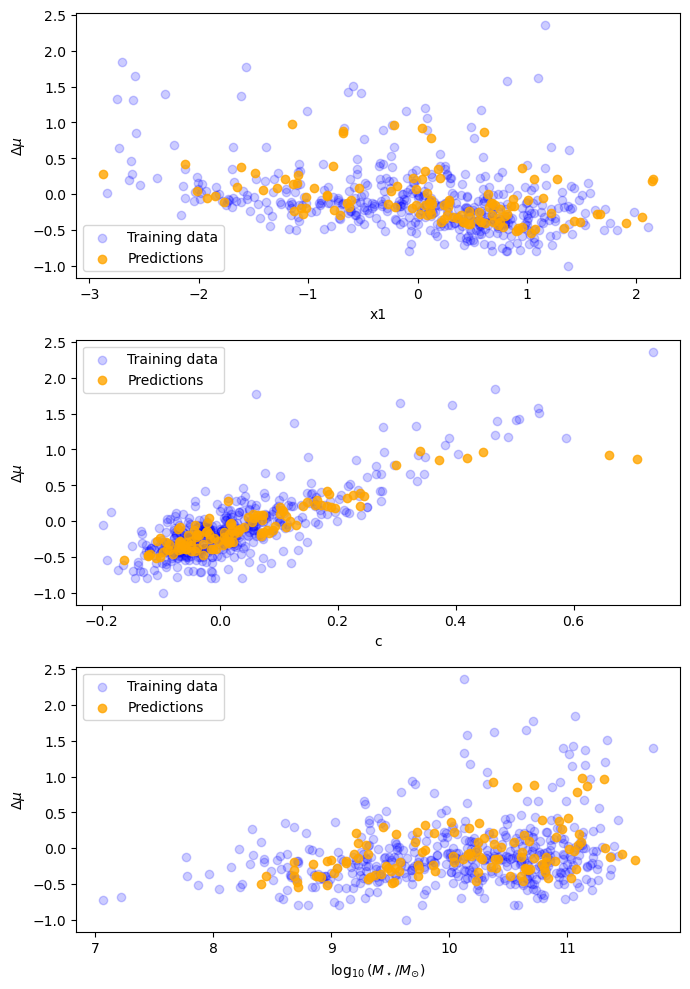

In [16]:
# =====================================================
# MI DAI ML TRAINING BLOCK 
# =====================================================

# Constructing the Random Forest Regressor Model
# Nothing is being fit here, uts just being made.

# Key properties of this model:
# - 1000 trees. 
# - Trees are allowed to grow deep (no max depth)
# - A minimum number of samples per leaf (5) enforces
#   local averaging and limits overfitting
# - At each split, only a subset of features is considered
#   (sqrt of total), encouraging diverse tree structures
# - Bootstrap resampling ensures each tree sees a slightly
#   different realization of the data

rf = RandomForestRegressor(
    n_estimators=1000,
    max_depth=None,
    min_samples_leaf=5,
    max_features="sqrt",
    bootstrap=True,
    n_jobs=-1,
    random_state=42,
)

# Defining Features and Setting Up Our Train/Test Split

features = {
    "x1": df_model["x1"].to_numpy(),
    "c": df_model["c"].to_numpy(),
    "hostmass": df_model["LOGMSTAR"].to_numpy(),
}

X = pd.DataFrame(features)
y = df_model[target_col].to_numpy()

# IMPORTANT: remove NaNs before train/test split (real data has missing values sometimes)
mask_ml = np.isfinite(X["x1"]) & np.isfinite(X["c"]) & np.isfinite(X["hostmass"]) & np.isfinite(y)
X = X.loc[mask_ml].reset_index(drop=True)
y = y[mask_ml.to_numpy()]

# Keep measurement errors aligned with X/y (so we can use per-point weights)
yerr = yerr_all.loc[df_model.index].to_numpy()
yerr = yerr[mask_ml.to_numpy()]

Xtr, Xte, ytr, yte = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# Defining standard error as well as weight and fitting the model 
# with all same weighst. In real code each data point would have its own weight to contribute to the fit.
# NOTE: in your real dataset you DO have per-point errors (sigma_mu_meas), so we use them here.
wtr = 1.0 / (yerr[train_test_split(
    np.arange(len(yerr)), test_size=0.2, random_state=42
)[0]]**2)

# The above line is a little hacky because train_test_split shuffles indices.
# Cleaner: compute weights AFTER the split using the same mask as Xtr.
# So instead, rebuild weights by splitting yerr alongside X and y.

Xtr, Xte, ytr, yte, yerr_tr, yerr_te = train_test_split(
    X, y, yerr, test_size=0.2, random_state=42
)

w = 1.0 / (yerr_tr**2)
rf.fit(Xtr, ytr, sample_weight=w)
yhat = rf.predict(Xte)

# Plots feature importance of x1, c, and hostmass in that order.
rf.feature_importances_

plt.figure(figsize=(7, 10))

# --------------------------------------
# x1
# --------------------------------------
plt.subplot(3, 1, 1)
plt.scatter(Xtr["x1"], ytr, alpha=0.2, color="blue", label="Training data")
plt.scatter(Xte["x1"], yhat, alpha=0.8, color="orange", label="Predictions")
plt.xlabel("x1")
plt.ylabel(r"$\Delta \mu$")
plt.legend()

# --------------------------------------
# c
# --------------------------------------
plt.subplot(3, 1, 2)
plt.scatter(Xtr["c"], ytr, alpha=0.2, color="blue", label="Training data")
plt.scatter(Xte["c"], yhat, alpha=0.8, color="orange", label="Predictions")
plt.xlabel("c")
plt.ylabel(r"$\Delta \mu$")
plt.legend()

# --------------------------------------
# hostmass (LOGMSTAR)
# --------------------------------------
plt.subplot(3, 1, 3)
plt.scatter(Xtr["hostmass"], ytr, alpha=0.2, color="blue", label="Training data")
plt.scatter(Xte["hostmass"], yhat, alpha=0.8, color="orange", label="Predictions")
plt.xlabel(r"$\log_{10}(M_\star / M_{\odot})$")
plt.ylabel(r"$\Delta \mu$")
plt.legend()

plt.tight_layout()
plt.show()

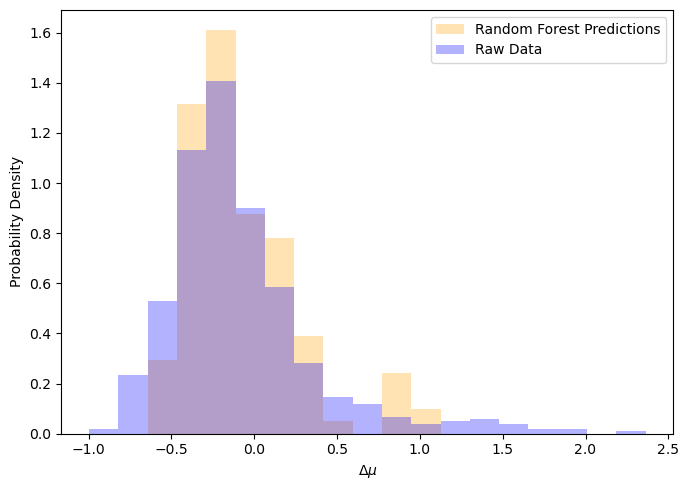

In [18]:
# --------------------------------------
# Compare distributions of raw residuals vs RF predictions
# --------------------------------------

bins = np.linspace(
    np.nanmin(y), 
    np.nanmax(y), 
    20
)

plt.figure(figsize=(7, 5))

# RF predictions (test set)
plt.hist(
    yhat,
    bins=bins,
    alpha=0.3,
    density=True,
    color="orange",
    label="Random Forest Predictions"
)

# Raw data (full sample)
plt.hist(
    y,
    bins=bins,
    alpha=0.3,
    density=True,
    color="blue",
    label="Raw Data"
)

plt.xlabel(r"$\Delta \mu$")
plt.ylabel("Probability Density")
plt.legend()
plt.tight_layout()
plt.show()

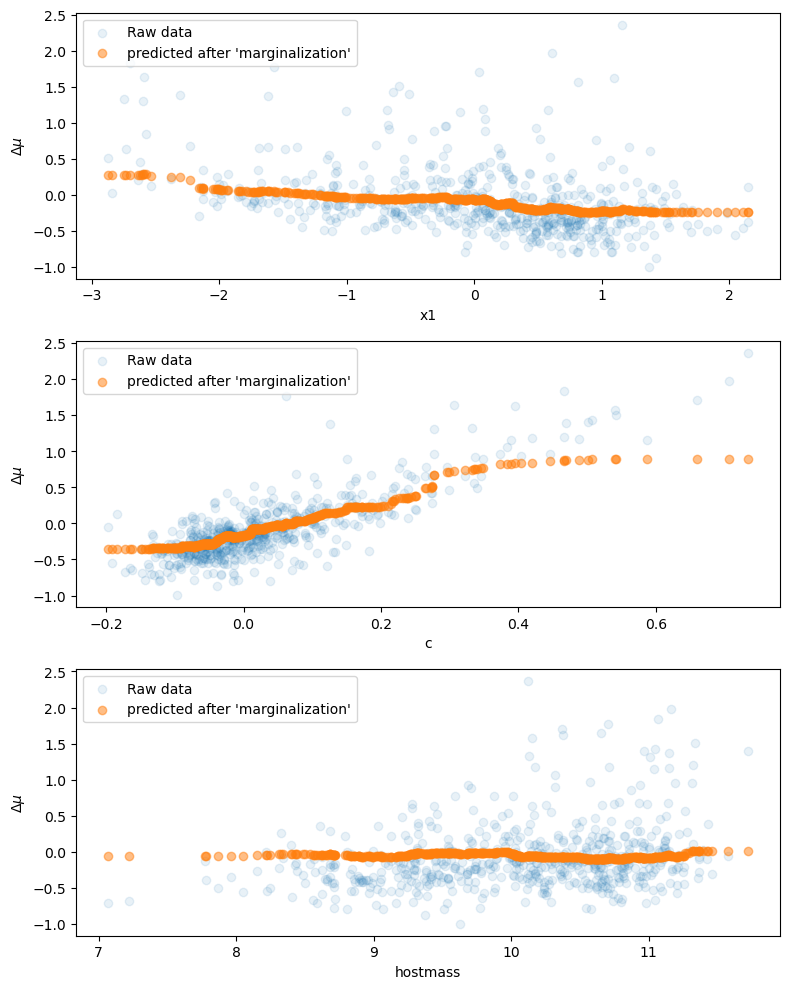

In [22]:
# =====================================================
# MEAN-FREEZING "MARGINALIZATION" PLOTS (PI SHORTCUT)
# =====================================================

# We have machine learning model where we can get x1 c and host mass and we get prediction of hubble residuals. Here there is no integration 
# being made but rather a mean value is taken. For Mykola: be sure to actually integrate as part of the marginalization process. 

# What is happening here is called "mean freezing". 

plt.figure(figsize=(8, 10))

# Loops through each of our host features.
for i,p in enumerate(["x1","c","hostmass"]):

    # frames subllots for our data. (i+1 is just an index here)
    plt.subplot(3,1,i+1)

    Xtest = X.copy() # Makes a copy of the features data frame. 

    # Look at the features x1, c, and hostmas. Ingore the one were currently on (p).
    # For each of the remianing features do the following.
    # "Loop thorugh the list of host mass parameter and if they're not equal to the 
    # current parameter p, then take the mean of the other 2  parameters 
    for p2 in [pi for pi in ["x1","c","hostmass"] if pi != p]:
        # Compute a mean of p2 parameters (replacing the whole collumn with the mean value of that column)
        Xtest[p2] = Xtest[p2].mean()
    
    # Predict the hubble residuals using the random forest model after mean averaging over the other 2 parameters.
    # You can use model to predict anything even your training data. 
    ytest = rf.predict(Xtest)

    plt.scatter(Xtest[p], y, alpha=0.1, label="Raw data")
    plt.scatter(Xtest[p], ytest, alpha=0.5, label="predicted after 'marginalization'")

    plt.xlabel(p)
    plt.ylabel(r'$\Delta\mu$')
    plt.legend()

plt.tight_layout()
plt.show()